Using device: cpu
Loaded 20000 tasks from /content/borg_traces_data.csv
Training VANILLA Dual DQN...
[vanilla] Episode 1/20 | AvgResp=7.679s, Success=79.00%, Util=0.1%, Cost=1645.68, SchedLoss=40.4813, ScaleLoss=1.3983
[vanilla] Episode 2/20 | AvgResp=7.677s, Success=78.93%, Util=0.2%, Cost=1569.79, SchedLoss=31.3182, ScaleLoss=0.5613
[vanilla] Episode 3/20 | AvgResp=7.845s, Success=78.10%, Util=0.1%, Cost=968.00, SchedLoss=41.1267, ScaleLoss=0.2006
[vanilla] Episode 4/20 | AvgResp=7.776s, Success=78.03%, Util=0.2%, Cost=1085.02, SchedLoss=49.3895, ScaleLoss=0.1444
[vanilla] Episode 5/20 | AvgResp=7.783s, Success=78.43%, Util=0.1%, Cost=1401.41, SchedLoss=61.7215, ScaleLoss=0.1146
[vanilla] Episode 6/20 | AvgResp=8.207s, Success=77.60%, Util=0.1%, Cost=760.55, SchedLoss=72.1236, ScaleLoss=0.0951
[vanilla] Episode 7/20 | AvgResp=17.621s, Success=69.57%, Util=0.2%, Cost=723.82, SchedLoss=86.0456, ScaleLoss=0.0681
[vanilla] Episode 8/20 | AvgResp=8.075s, Success=77.63%, Util=0.2%, Cost=78

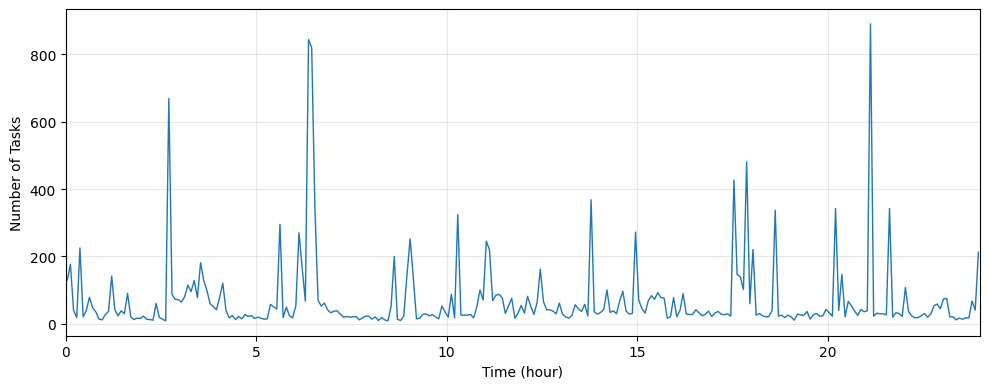

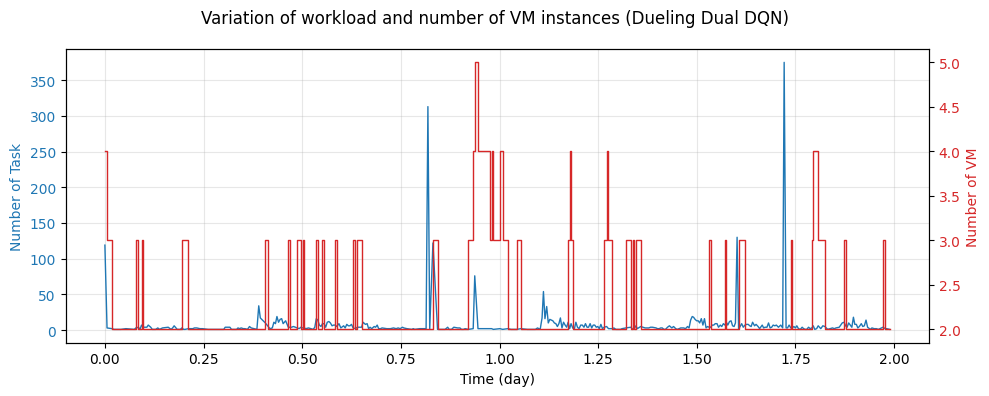

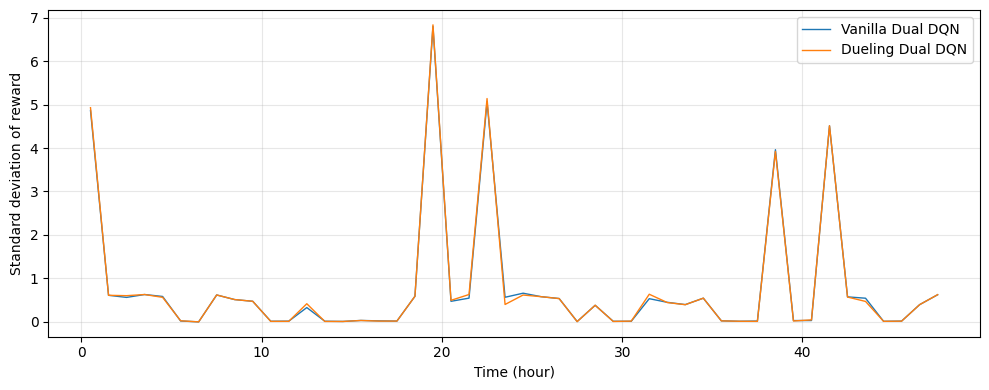

In [1]:
# ============================================================
# 0. IMPORTS & DEVICE
# ============================================================
import math
import random
import ast
from collections import deque, namedtuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt  # <-- added for plotting

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================================
# 1. LOAD & PREPROCESS GOOGLE CLUSTER DATA
# ============================================================

def load_tasks_from_google_trace(
    csv_path,
    max_tasks=20000,
    base_len=10.0,
    interactive_qos=5.0,
    batch_qos=20.0,
    cpu_heavy_threshold=1.0
):
    """
    Reads the Google 2019 cluster sample CSV and returns a list of tasks:
      - arrival_time (seconds, starting at 0)
      - task_type: 1 = interactive, 0 = batch
      - length: work units
      - qos: acceptable response time
      - cpus: requested CPU
      - profile: 'cpu' or 'mem' for heterogeneity
    """
    df = pd.read_csv(csv_path)

    if 'event' in df.columns:
        df = df[df['event'] == 'SCHEDULE']
    df = df.sort_values('time')

    tasks = []
    t0 = None
    has_resource_req = 'resource_request' in df.columns

    for _, row in df.iterrows():
        if len(tasks) >= max_tasks:
            break

        time_val = float(row['time'])
        if t0 is None:
            t0 = time_val
        # assume microseconds; convert to seconds
        arrival = (time_val - t0) / 1e6
        arrival = max(0.0, arrival)

        # scheduling_class -> interactive vs batch
        sc = int(row.get('scheduling_class', 0))
        if sc <= 1:
            task_type = 1  # interactive
        else:
            task_type = 0  # batch

        # requested cpus from JSON-like resource_request
        cpus = 0.5
        if has_resource_req:
            try:
                rr = ast.literal_eval(row['resource_request'])
                if isinstance(rr, dict) and 'cpus' in rr:
                    cpus = float(rr['cpus'])
            except Exception:
                pass

        length = max(1e-3, cpus * base_len)
        qos = interactive_qos if task_type == 1 else batch_qos

        profile = 'cpu' if cpus >= cpu_heavy_threshold else 'mem'

        tasks.append({
            'arrival_time': arrival,
            'task_type': task_type,
            'length': length,
            'qos': qos,
            'cpus': cpus,
            'profile': profile
        })

    print(f"Loaded {len(tasks)} tasks from {csv_path}")
    return tasks


# ---- SET YOUR CSV PATH HERE ----
CSV_PATH = "/content/borg_traces_data.csv"  # change this to your file
tasks = load_tasks_from_google_trace(CSV_PATH, max_tasks=20000)
len(tasks)


# ============================================================
# 2. ENVIRONMENT WITH HETEROGENEOUS VMs & TIME-BASED SCALING
# ============================================================

class VM:
    def __init__(self, vm_id, vm_type, speed_cpu, speed_mem):
        self.id = vm_id
        self.vm_type = vm_type  # 'cpu' or 'mem'
        self.speed_cpu = speed_cpu
        self.speed_mem = speed_mem
        self.busy_until = 0.0


class ClusterEnv:
    """
    Environment with:
      - Heterogeneous VMs: CPU-optimized & MEM-optimized
      - Dual decision:
          * Layer 1: task scheduling (per-task)
          * Layer 2: VM autoscaling (time-based)
      - Autoscaler reward includes QoS, utilization, and cost
    """
    def __init__(
        self,
        tasks,
        max_vms=10,
        min_vms=2,
        initial_vms=5,
        vm_price_per_sec=0.125/60.0,  # $0.125 per minute -> per second
        scale_interval_time=300.0,     # 5 minutes
        cpu_vm_speed=(2.0, 1.0),       # (speed_cpu, speed_mem) for CPU-optimized
        mem_vm_speed=(1.0, 2.0),       # (speed_cpu, speed_mem) for MEM-optimized
        max_tasks_per_interval=1000,
        autoscaler_beta=0.05
    ):
        self.all_tasks = tasks
        self.num_tasks = len(tasks)

        self.max_vms = max_vms
        self.min_vms = min_vms
        self.initial_vms = initial_vms
        self.vm_price = vm_price_per_sec
        self.scale_interval_time = scale_interval_time
        self.max_tasks_per_interval = max_tasks_per_interval
        self.autoscaler_beta = autoscaler_beta

        self.cpu_vm_speed = cpu_vm_speed
        self.mem_vm_speed = mem_vm_speed

        self.vms = None
        self.num_vms = None
        self.task_idx = None

        # Episode-level metrics
        self.total_cost = 0.0
        self.total_success = 0
        self.total_tasks = 0
        self.total_response_time = 0.0
        self.total_exec_time = 0.0
        self.global_busy_time = 0.0

        self.start_time = 0.0
        self.end_time = 0.0

        # Time-based scaling
        self.last_scale_time = 0.0

        self.reset_interval_metrics()

        # ---------- added for plotting (no logic change) ----------
        self.time_history = []        # time of each autoscaling decision
        self.workload_history = []    # number of tasks in the last interval
        self.num_vms_history = []     # VM count after each scaling decision
        self.autoscale_times = []     # same as time_history but used for reward plot
        self.autoscale_rewards = []   # reward at each autoscale step
        # ----------------------------------------------------------

    def reset_interval_metrics(self):
        self.interval_task_count = 0
        self.interval_success = 0
        self.interval_response_time = 0.0
        self.interval_exec_time = 0.0
        self.interval_busy_time = 0.0
        self.interval_start_time = None
        self.interval_end_time = None
        self.interval_prev_num_vms = (
            self.num_vms if getattr(self, "num_vms", None) is not None
            else self.initial_vms
        )

    def reset(self):
        # Create heterogeneous VM pool
        self.vms = []
        half = self.max_vms // 2
        # CPU-optimized first half
        for i in range(half):
            vm = VM(
                vm_id=i,
                vm_type='cpu',
                speed_cpu=self.cpu_vm_speed[0],
                speed_mem=self.cpu_vm_speed[1]
            )
            self.vms.append(vm)
        # MEM-optimized second half
        for i in range(half, self.max_vms):
            vm = VM(
                vm_id=i,
                vm_type='mem',
                speed_cpu=self.mem_vm_speed[0],
                speed_mem=self.mem_vm_speed[1]
            )
            self.vms.append(vm)

        self.num_vms = self.initial_vms
        for vm in self.vms:
            vm.busy_until = 0.0

        self.task_idx = 0

        self.total_cost = 0.0
        self.total_success = 0
        self.total_tasks = 0
        self.total_response_time = 0.0
        self.total_exec_time = 0.0
        self.global_busy_time = 0.0

        if self.all_tasks:
            self.start_time = self.all_tasks[0]['arrival_time']
        else:
            self.start_time = 0.0
        self.end_time = self.start_time
        self.last_scale_time = self.start_time

        self.reset_interval_metrics()

        # reset histories for new episode (for plotting)
        self.time_history = []
        self.workload_history = []
        self.num_vms_history = []
        self.autoscale_times = []
        self.autoscale_rewards = []

        return self.get_scheduler_state()

    # ---------- Helpers ----------

    def current_task(self):
        if self.task_idx >= self.num_tasks:
            return None
        return self.all_tasks[self.task_idx]

    def vm_wait_time_if_assigned(self, vm, arrival_time):
        return max(0.0, vm.busy_until - arrival_time)

    def task_execution_time(self, task, vm):
        # Heterogeneous speeds based on task profile
        if task['profile'] == 'cpu':
            return task['length'] / vm.speed_cpu
        else:
            return task['length'] / vm.speed_mem

    def assign_task_to_vm(self, task, vm_id):
        vm = self.vms[vm_id]
        arrival = task['arrival_time']
        exeT = self.task_execution_time(task, vm)

        start_time = max(arrival, vm.busy_until)
        finish_time = start_time + exeT
        waitT = start_time - arrival
        totalT = finish_time - arrival

        success = 1 if totalT <= task['qos'] else 0

        vm.busy_until = finish_time

        if self.total_tasks == 0:
            self.start_time = arrival
        self.end_time = max(self.end_time, finish_time)

        self.total_tasks += 1
        self.total_success += success
        self.total_response_time += totalT
        self.total_exec_time += exeT
        self.global_busy_time += exeT

        # Interval stats
        if self.interval_start_time is None:
            self.interval_start_time = arrival
        self.interval_end_time = finish_time
        self.interval_task_count += 1
        self.interval_success += success
        self.interval_response_time += totalT
        self.interval_exec_time += exeT
        self.interval_busy_time += exeT

        return totalT, exeT, waitT, success

    def compute_interval_stats(self):
        if self.interval_task_count == 0:
            return 0, self.interval_prev_num_vms, 0.0, 1.0, 0.0

        N_prev = self.interval_task_count
        M_prev = self.interval_prev_num_vms
        avgT_prev = self.interval_response_time / N_prev
        suc_prev = self.interval_success / N_prev

        interval_span = 1e-6
        if self.interval_end_time is not None and self.interval_start_time is not None:
            interval_span = max(interval_span, self.interval_end_time - self.interval_start_time)

        util_prev = min(1.0, self.interval_busy_time / (M_prev * interval_span))

        return N_prev, M_prev, avgT_prev, suc_prev, util_prev

    def episode_utilization(self):
        time_span = max(1e-6, self.end_time - self.start_time)
        avg_m = self.num_vms
        util = self.global_busy_time / (avg_m * time_span)
        util = max(0.0, min(1.0, util))
        return util

    # ---------- Autoscaler interface ----------

    def should_scale(self):
        # Time-based scaling condition
        if (self.end_time - self.last_scale_time) >= self.scale_interval_time:
            return True
        return False

    def get_autoscaler_state(self):
        # Normalized features for autoscaler
        N_prev, M_prev, avgT_prev, suc_prev, util_prev = self.compute_interval_stats()

        # Normalization
        N_norm = min(1.0, N_prev / max(1.0, self.max_tasks_per_interval))
        M_norm = M_prev / float(self.max_vms)
        # Assume typical QoS bound ~20s for normalization
        avgT_norm = min(1.0, avgT_prev / 20.0)
        suc_norm = suc_prev  # already in [0,1]
        util_norm = util_prev
        time_of_day = (self.end_time % (24*3600)) / (24*3600)

        state = np.array(
            [N_norm, M_norm, avgT_norm, suc_norm, util_norm, time_of_day],
            dtype=np.float32
        )
        return state

    def step_autoscaler(self, action_idx, scale_actions):
        N_prev, M_prev, avgT_prev, suc_prev, util_prev = self.compute_interval_stats()

        time_span = 1e-6
        if self.interval_end_time is not None and self.interval_start_time is not None:
            time_span = max(time_span, self.interval_end_time - self.interval_start_time)

        interval_cost = time_span * self.num_vms * self.vm_price
        self.total_cost += interval_cost

        # Penalty term as in paper (but we SUBTRACT it)
        if suc_prev >= 0.9:
            P = 0.0
        else:
            P = math.exp(0.9 - suc_prev) + 0.8
        alpha = 5.0

        # Cost ratio relative to "max possible cost" in this interval
        max_interval_cost = self.scale_interval_time * self.max_vms * self.vm_price + 1e-8
        cost_ratio = interval_cost / max_interval_cost

        # FIXED: reward decreases when success drops (subtract alpha * P)
        reward = math.log(5.0 * util_prev + 1.0) - alpha * P - self.autoscaler_beta * cost_ratio

        # Adjust VM count
        delta = scale_actions[action_idx]
        new_num_vms = self.num_vms + delta
        new_num_vms = max(self.min_vms, min(self.max_vms, new_num_vms))

        # ----- logging for plots (no effect on logic) -----
        # use end_time as current time, N_prev = tasks in this interval
        self.time_history.append(self.end_time)
        self.workload_history.append(N_prev)
        self.num_vms_history.append(new_num_vms)
        self.autoscale_times.append(self.end_time)
        self.autoscale_rewards.append(reward)
        # --------------------------------------------------

        if new_num_vms < self.num_vms:
            # Shrink: remove least loaded VMs (smallest busy_until first)
            active_ids = list(range(self.num_vms))
            sorted_ids = sorted(active_ids, key=lambda i: self.vms[i].busy_until)
            # keep VMs with highest busy_until, i.e., drop smallest
            keep_ids = sorted(sorted_ids[(self.num_vms - new_num_vms):])
            new_vms = []
            for new_id, old_id in enumerate(keep_ids):
                vm = self.vms[old_id]
                vm.id = new_id
                new_vms.append(vm)
            # pad remaining
            for new_id in range(new_num_vms, self.max_vms):
                vm = self.vms[new_id]
                vm.id = new_id
                vm.busy_until = self.end_time
                new_vms.append(vm)
            self.vms = new_vms

        self.num_vms = new_num_vms
        self.interval_prev_num_vms = self.num_vms
        self.reset_interval_metrics()
        self.last_scale_time = self.end_time

        next_state = self.get_autoscaler_state()
        return next_state, reward

    # ---------- Scheduler interface ----------

    def get_scheduler_state(self):
        task = self.current_task()
        if task is None:
            # zeros when no task
            return np.zeros(1 + self.max_vms, dtype=np.float32)

        arrival = task['arrival_time']
        ttype = float(task['task_type'])
        waits = []
        for j in range(self.max_vms):
            if j < self.num_vms:
                w = self.vm_wait_time_if_assigned(self.vms[j], arrival)
                # Normalize waiting by QoS (clipped)
                w_norm = min(1.0, w / max(1e-6, task['qos']))
                waits.append(w_norm)
            else:
                waits.append(0.0)

        state = np.array([ttype] + waits, dtype=np.float32)
        return state

    def step_scheduler(self, vm_action_index):
        task = self.current_task()
        if task is None:
            return self.get_scheduler_state(), 0.0, True, {}

        if self.num_vms <= 0:
            vm_id = 0
        else:
            vm_id = vm_action_index % self.num_vms

        totalT, exeT, waitT, success = self.assign_task_to_vm(task, vm_id)

        # Weighted reward: interactive tasks more important
        w = 2.0 if task['task_type'] == 1 else 1.0
        raw = -w * (totalT / max(exeT, 1e-6))
        # Clip extreme negative rewards
        R_max = 20.0
        reward = max(raw, -R_max)

        self.task_idx += 1
        done = (self.task_idx >= self.num_tasks)

        next_state = self.get_scheduler_state()
        info = {
            'totalT': totalT,
            'exeT': exeT,
            'waitT': waitT,
            'success': success,
            'task_type': task['task_type']
        }
        return next_state, reward, done, info


# ============================================================
# 3. NETWORKS: VANILLA & DUELING Q-NETWORKS
# ============================================================

Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))

class QNetwork(nn.Module):
    """Standard Q-network."""
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


class DuelingQNetwork(nn.Module):
    """Dueling network: separate value and advantage heads."""
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)

        self.value_head = nn.Linear(hidden_dim, 1)
        self.adv_head = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        value = self.value_head(x)                 # [B, 1]
        adv = self.adv_head(x)                    # [B, A]
        adv_mean = adv.mean(dim=1, keepdim=True)  # [B, 1]

        q = value + (adv - adv_mean)
        return q


# ============================================================
# 4. DQN AGENT (Double DQN + optional Dueling)
# ============================================================

class DQNAgent:
    def __init__(
        self,
        state_dim,
        action_dim,
        dueling=False,
        lr=1e-3,
        gamma=0.95,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay=5000,
        buffer_size=50000,
        batch_size=64,
        target_update=500
    ):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update = target_update

        if dueling:
            self.policy_net = DuelingQNetwork(state_dim, action_dim).to(device)
            self.target_net = DuelingQNetwork(state_dim, action_dim).to(device)
        else:
            self.policy_net = QNetwork(state_dim, action_dim).to(device)
            self.target_net = QNetwork(state_dim, action_dim).to(device)

        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)

        self.memory = deque(maxlen=buffer_size)
        self.steps_done = 0

        self.epsilon_start = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay

    def select_action(self, state):
        self.steps_done += 1
        eps = self.epsilon_end + (self.epsilon_start - self.epsilon_end) * \
              math.exp(-1.0 * self.steps_done / self.epsilon_decay)
        if random.random() < eps:
            return random.randrange(self.action_dim)
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            q_vals = self.policy_net(s)
            return int(q_vals.argmax(dim=1).item())

    def store(self, state, action, reward, next_state, done):
        self.memory.append(Transition(state, action, reward, next_state, done))

    def optimize(self):
        if len(self.memory) < self.batch_size:
            return None

        transitions = random.sample(self.memory, self.batch_size)
        batch = Transition(*zip(*transitions))

        state_batch = torch.tensor(np.stack(batch.state), dtype=torch.float32, device=device)
        action_batch = torch.tensor(batch.action, dtype=torch.int64, device=device).unsqueeze(1)
        reward_batch = torch.tensor(batch.reward, dtype=torch.float32, device=device).unsqueeze(1)
        next_state_batch = torch.tensor(np.stack(batch.next_state), dtype=torch.float32, device=device)
        done_batch = torch.tensor(batch.done, dtype=torch.float32, device=device).unsqueeze(1)

        # Q(s,a)
        q_values = self.policy_net(state_batch).gather(1, action_batch)

        # Double DQN target
        with torch.no_grad():
            next_q_policy = self.policy_net(next_state_batch)
            next_actions = next_q_policy.argmax(dim=1, keepdim=True)
            next_q_target = self.target_net(next_state_batch).gather(1, next_actions)
            target_q = reward_batch + self.gamma * next_q_target * (1.0 - done_batch)

        loss = F.mse_loss(q_values, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()

        if self.steps_done % self.target_update == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return loss.item()

    def set_greedy(self):
        self.epsilon_start = 0.0
        self.epsilon_end = 0.0
        self.epsilon_decay = 1.0


# ============================================================
# 5. TRAINING & EVALUATION
# ============================================================

def train_dual_dqn(env_tasks, agent_type='vanilla', num_episodes=10, max_tasks_per_episode=3000):
    """
    Train dual-layer agent (scheduler + autoscaler) on given tasks.
    agent_type: 'vanilla' or 'dueling'
    """
    dueling = (agent_type == 'dueling')

    env = ClusterEnv(
        env_tasks[:max_tasks_per_episode],
        max_vms=10,
        min_vms=2,
        initial_vms=5,
        vm_price_per_sec=0.125/60.0,
        scale_interval_time=300.0,
        max_tasks_per_interval=1000,
        autoscaler_beta=0.1
    )

    # Scheduler DQN
    sched_state_dim = 1 + env.max_vms
    sched_action_dim = env.max_vms
    sched_agent = DQNAgent(
        sched_state_dim,
        sched_action_dim,
        dueling=dueling,
        lr=1e-4,
        gamma=0.9,
        epsilon_decay=8000,
        target_update=1000,
        buffer_size=50000,
        batch_size=64
    )

    # Autoscaler DQN
    scale_state_dim = 6
    scale_actions = [-1, 0, +1]
    scale_agent = DQNAgent(
        scale_state_dim,
        len(scale_actions),
        dueling=dueling,
        lr=5e-4,
        gamma=0.95,
        epsilon_decay=5000,
        target_update=500,
        buffer_size=30000,
        batch_size=64
    )

    ep_results = []

    for ep in range(num_episodes):
        state_sched = env.reset()
        done = False
        sched_losses, scale_losses = [], []

        while not done:
            # ----- Layer 1: scheduler -----
            a_sched = sched_agent.select_action(state_sched)
            next_sched, r_sched, done, info = env.step_scheduler(a_sched)
            sched_agent.store(state_sched, a_sched, r_sched, next_sched, float(done))
            loss_s = sched_agent.optimize()
            if loss_s is not None:
                sched_losses.append(loss_s)
            state_sched = next_sched

            # ----- Layer 2: autoscaler (time-based trigger) -----
            if env.should_scale() or done:
                s_scale = env.get_autoscaler_state()
                a_scale_idx = scale_agent.select_action(s_scale)
                s_next_scale, r_scale = env.step_autoscaler(a_scale_idx, scale_actions)
                scale_agent.store(s_scale, a_scale_idx, r_scale, s_next_scale, float(done))
                loss_sc = scale_agent.optimize()
                if loss_sc is not None:
                    scale_losses.append(loss_sc)

        avg_resp = env.total_response_time / max(1, env.total_tasks)
        success_rate = env.total_success / max(1, env.total_tasks)
        util = env.episode_utilization()
        cost = env.total_cost

        ep_results.append((avg_resp, success_rate, util, cost))

        print(f"[{agent_type}] Episode {ep+1}/{num_episodes} | "
              f"AvgResp={avg_resp:.3f}s, Success={success_rate*100:.2f}%, "
              f"Util={util*100:.1f}%, Cost={cost:.2f}, "
              f"SchedLoss={np.mean(sched_losses) if sched_losses else 0:.4f}, "
              f"ScaleLoss={np.mean(scale_losses) if scale_losses else 0:.4f}")

    return env, sched_agent, scale_agent, ep_results


def evaluate_dual_dqn(env_tasks, sched_agent, scale_agent, max_tasks_per_episode=3000):
    """
    Evaluate given trained agents with greedy policy (epsilon=0).
    """
    sched_agent.set_greedy()
    scale_agent.set_greedy()

    env = ClusterEnv(
        env_tasks[:max_tasks_per_episode],
        max_vms=10,
        min_vms=2,
        initial_vms=5,
        vm_price_per_sec=0.125/60.0,
        scale_interval_time=300.0,
        max_tasks_per_interval=1000,
        autoscaler_beta=0.1
    )
    scale_actions = [-1, 0, +1]

    state_sched = env.reset()
    done = False

    while not done:
        a_sched = sched_agent.select_action(state_sched)
        next_sched, r_sched, done, info = env.step_scheduler(a_sched)
        state_sched = next_sched

        if env.should_scale() or done:
            s_scale = env.get_autoscaler_state()
            a_scale_idx = scale_agent.select_action(s_scale)
            _next, _r = env.step_autoscaler(a_scale_idx, scale_actions)

    avg_resp = env.total_response_time / max(1, env.total_tasks)
    success_rate = env.total_success / max(1, env.total_tasks)
    util = env.episode_utilization()
    cost = env.total_cost

    return avg_resp, success_rate, util, cost


# ============================================================
# 6. RUN TRAINING FOR VANILLA & DUELING DUAL DQN (10 EPISODES)
# ============================================================

NUM_EPISODES = 20
MAX_TASKS_EP = 3000  # reduce for faster runs

print("Training VANILLA Dual DQN...")
env_vanilla, sched_vanilla, scale_vanilla, res_vanilla = train_dual_dqn(
    tasks,
    agent_type='vanilla',
    num_episodes=NUM_EPISODES,
    max_tasks_per_episode=MAX_TASKS_EP
)

print("\nTraining DUELING Dual DQN...")
env_dueling, sched_dueling, scale_dueling, res_dueling = train_dual_dqn(
    tasks,
    agent_type='dueling',
    num_episodes=NUM_EPISODES,
    max_tasks_per_episode=MAX_TASKS_EP
)


# ============================================================
# 7. EVALUATE AND COMPARE
# ============================================================

avg_resp_v, suc_v, util_v, cost_v = evaluate_dual_dqn(tasks, sched_vanilla, scale_vanilla, MAX_TASKS_EP)
avg_resp_d, suc_d, util_d, cost_d = evaluate_dual_dqn(tasks, sched_dueling, scale_dueling, MAX_TASKS_EP)

comparison_rows = [
    {
        'Algorithm': 'DualVanillaDQN',
        'AvgResp(s)': round(avg_resp_v, 3),
        'SuccessRate(%)': round(suc_v * 100, 2),
        'Utilization(%)': round(util_v * 100, 2),
        'RentalCost': round(cost_v, 2)
    },
    {
        'Algorithm': 'DualDuelingDQN',
        'AvgResp(s)': round(avg_resp_d, 3),
        'SuccessRate(%)': round(suc_d * 100, 2),
        'Utilization(%)': round(util_d * 100, 2),
        'RentalCost': round(cost_d, 2)
    }
]

df_compare = pd.DataFrame(comparison_rows)
print(df_compare)


# ============================================================
# 8. PLOTTING FUNCTIONS (added)
# ============================================================

def plot_daily_workload(tasks, bin_minutes=5):
    """
    Fig. 4 style: Number of tasks vs time (hour) in a day.
    """
    arr_sec = np.array([t['arrival_time'] for t in tasks])
    hours = (arr_sec / 3600.0) % 24.0

    bin_width_hour = bin_minutes / 60.0
    bins = np.arange(0.0, 24.0 + bin_width_hour, bin_width_hour)
    counts, edges = np.histogram(hours, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])

    plt.figure(figsize=(10, 4))
    plt.plot(centers, counts, linewidth=1.0)
    plt.xlabel("Time (hour)")
    plt.ylabel("Number of Tasks")
    plt.xlim(0, 24)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_workload_vs_vms(env, title="Variation of workload and number of VM instances"):
    """
    Fig. 5 style: workload (tasks per autoscale interval) and number of VMs vs time (day).
    Uses histories recorded during the last training episode of 'env'.
    """
    times = np.array(env.time_history)
    if len(times) == 0:
        print("No autoscaling history recorded in env.time_history")
        return

    time_days = (times - times[0]) / (24.0 * 3600.0)
    workload = np.array(env.workload_history)
    vms = np.array(env.num_vms_history)

    fig, ax1 = plt.subplots(figsize=(10, 4))

    ax1.plot(time_days, workload, color="tab:blue", linewidth=1.0)
    ax1.set_xlabel("Time (day)")
    ax1.set_ylabel("Number of Task", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.step(time_days, vms, where="post", color="tab:red", linewidth=1.0)
    ax2.set_ylabel("Number of VM", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def plot_std_reward_over_time(env_list, labels, bin_hours=1.0):
    """
    Fig. style: Standard deviation of reward vs time (hour) for several configurations.
    env_list : list of ClusterEnv objects (e.g., trained with different settings).
    labels   : legend labels for each env.
    """
    plt.figure(figsize=(10, 4))

    for env, label in zip(env_list, labels):
        times = np.array(env.autoscale_times)
        rewards = np.array(env.autoscale_rewards)
        if len(times) == 0:
            continue

        t_hours = (times - times[0]) / 3600.0
        t_max = t_hours.max()
        bins = np.arange(0.0, t_max + bin_hours, bin_hours)
        idx = np.digitize(t_hours, bins) - 1

        stds = []
        centers = []
        for i in range(len(bins) - 1):
            mask = (idx == i)
            if np.any(mask):
                stds.append(np.std(rewards[mask]))
            else:
                stds.append(0.0)
            centers.append(0.5 * (bins[i] + bins[i + 1]))

        plt.plot(centers, stds, linewidth=1.0, label=label)

    plt.xlabel("Time (hour)")
    plt.ylabel("Standard deviation of reward")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# 9. GENERATE THE FIGURES
# ============================================================

# Fig. 4 style: workload in a day
plot_daily_workload(tasks)

# Fig. 5 style: workload vs VM instances (use last dueling episode as example)
plot_workload_vs_vms(env_dueling, title="Variation of workload and number of VM instances (Dueling Dual DQN)")

# Reward standard deviation vs time, comparing vanilla and dueling
plot_std_reward_over_time(
    env_list=[env_vanilla, env_dueling],
    labels=["Vanilla Dual DQN", "Dueling Dual DQN"],
    bin_hours=1.0
)